# Machine Learning for Urban Air Quality — **Separated by City**
### Monthly Modeling for NYC and LA — Targets: PM2.5, NO2, Ozone, CO
_Auto-generated: 2025-08-24 12:38 UTC_

**Key constraints implemented exactly as requested:**
- **NYC and LA handled separately** (never merged).
- **Monthly** aggregation prior to modeling.
- **Per-model, per-city plots** (Random Forest, XGBoost, MLP, LSTM).
- **Time-based 80/10/10** split.
- **SHAP & LIME** explainability at the end (RF-based, per pollutant per city).


## 0. Environment & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# XGBoost
try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception as e:
    XGB_AVAILABLE = False
    print("XGBoost not available:", e)

# Keras (LSTM)
try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, LSTM, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    KERAS_AVAILABLE = True
except Exception as e:
    KERAS_AVAILABLE = False
    print("TensorFlow/Keras not available:", e)

# Explainability
try:
    import shap
    SHAP_AVAILABLE = True
except Exception as e:
    SHAP_AVAILABLE = False
    print("SHAP not available:", e)

try:
    from lime.lime_tabular import LimeTabularExplainer
    LIME_AVAILABLE = True
except Exception as e:
    LIME_AVAILABLE = False
    print("LIME not available:", e)

pd.set_option("display.max_columns", 200)
SEED = 42
np.random.seed(SEED)

LIME not available: No module named 'lime'


## 1. Configuration — Paths, Columns, Pollutants

In [2]:
from google.colab import files
uploaded = files.upload()
CITY_FILES = [
  "LA_Data.csv",
  "NYC_Data.csv"
]  # expects one NYC file and one LA file

# Timestamp column
TIMESTAMP_COL = "Date"

# Pollutants of interest (robust column matching is implemented below)
POLLUTANTS = ["PM2.5", "NO2", "Ozone", "CO"]

# Monthly modeling
RESAMPLE_RULE = "M"  # month-end

# Train/Val/Test fractions
TRAIN_FRAC = 0.80
VAL_FRAC = 0.10  # test is implied: 1 - TRAIN_FRAC - VAL_FRAC

# LSTM sequence length in months
SEQ_LEN = 6  # keep modest for monthly data

Saving NYC_Data.csv to NYC_Data.csv
Saving LA_Data.csv to LA_Data.csv


## 2. Utilities

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# XGBoost
try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception as e:
    XGB_AVAILABLE = False
    print("XGBoost not available:", e)

# Keras (LSTM)
try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, LSTM, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    KERAS_AVAILABLE = True
except Exception as e:
    KERAS_AVAILABLE = False
    print("TensorFlow/Keras not available:", e)

# Explainability
try:
    import shap
    SHAP_AVAILABLE = True
except Exception as e:
    SHAP_AVAILABLE = False
    print("SHAP not available:", e)

try:
    from lime.lime_tabular import LimeTabularExplainer
    LIME_AVAILABLE = True
except Exception as e:
    LIME_AVAILABLE = False
    print("LIME not available:", e)

pd.set_option("display.max_columns", 200)
SEED = 42
np.random.seed(SEED)

def load_city_df(path, city_name, ts_col):
    if path.lower().endswith(".csv"):
        df = pd.read_csv(path)
    else:
        df = pd.read_parquet(path)
    # timestamp
    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
    df = df.dropna(subset=[ts_col]).sort_values(ts_col).reset_index(drop=True)
    df["__city__"] = city_name
    return df

def guess_city_name_from_path(path):
    base = os.path.basename(path).lower()
    if "ny" in base:
        return "NYC"
    if "la" in base or "los_angeles" in base or "los-angeles" in base:
        return "LA"
    return os.path.splitext(os.path.basename(path))[0]

def normalize_col(s):
    return (
        s.lower()
        .replace(".", "")
        .replace("_", "")
        .replace("-", "")
        .replace(" ", "")
    )

# try to map a logical pollutant name to a real column in the dataframe (case and punctuation insensitive)
def resolve_column(df, logical_name):
    variants = {
        "pm2.5": ["pm2.5", "pm25", "pm2_5", "finepm", "pm25ugm3"],
        "no2": ["no2", "nitrogendioxide", "nitrogendioxide_no2"],
        "ozone": ["ozone", "o3"],
        "co": ["co", "carbonmonoxide"]
    }
    target_norms = variants.get(logical_name.lower(), [logical_name.lower()])
    # Build a map of normalized->original
    normmap = {normalize_col(c): c for c in df.columns}
    for norm in target_norms:
        if norm in normmap:
            return normmap[norm]
    # Fallback: fuzzy prefix search
    for k, orig in normmap.items():
        for t in target_norms:
            if t in k:
                return orig
    raise KeyError(f"Could not resolve column for target '{logical_name}'. Available columns: {list(df.columns)}")

def monthly_aggregate(df, ts_col):
    # aggregate by month for each numeric column
    df = df.set_index(ts_col)
    monthly = df.resample(RESAMPLE_RULE).mean(numeric_only=True)
    monthly = monthly.reset_index()
    return monthly

def time_split(df, X, y, train_frac=0.8, val_frac=0.1):
    n = len(df)
    n_train = int(n * train_frac)
    n_val = int(n * (train_frac + val_frac))
    idx_train = slice(0, n_train)
    idx_val   = slice(n_train, n_val)
    idx_test  = slice(n_val, n)

    return (X.iloc[idx_train], y.iloc[idx_train], df.iloc[idx_train]), \
           (X.iloc[idx_val],   y.iloc[idx_val],   df.iloc[idx_val]), \
           (X.iloc[idx_test],  y.iloc[idx_test],  df.iloc[idx_test])

def evaluate_regression(y_true, y_pred, label=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{label} MAE: {mae:.4f} | RMSE: {rmse:.4f} | R^2: {r2:.4f}")
    return dict(MAE=mae, RMSE=rmse, R2=r2)

def plot_predictions(df_part, y_true, y_pred, ts_col, city, pollutant, title_suffix):
    plt.figure()
    plt.plot(df_part[ts_col].values, y_true, label="Actual")
    plt.plot(df_part[ts_col].values, y_pred, label="Predicted")
    plt.title(f"{city} — {pollutant} — {title_suffix}")
    plt.xlabel("Time")
    plt.ylabel(pollutant)
    plt.legend()
    plt.show()

def make_sequences(X_arr, y_arr, seq_len):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X_arr)):
        X_seq.append(X_arr[i-seq_len:i])
        y_seq.append(y_arr[i])
    return np.array(X_seq), np.array(y_seq)

LIME not available: No module named 'lime'


## 3. Load Data for Each City (Kept Separate) + Monthly Aggregation

In [5]:
city_dfs = {}
for path in CITY_FILES:
    city_name = guess_city_name_from_path(path)
    df = load_city_df(path, city_name, TIMESTAMP_COL)
    monthly = monthly_aggregate(df, TIMESTAMP_COL)
    monthly[TIMESTAMP_COL] = pd.to_datetime(monthly[TIMESTAMP_COL])
    city_dfs[city_name] = monthly
    print(city_name, "monthly shape:", monthly.shape)

list(city_dfs.keys())

/tmp/ipython-input-4007753178.py:53: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.resample(RESAMPLE_RULE).mean(numeric_only=True)
/tmp/ipython-input-4007753178.py:53: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.resample(RESAMPLE_RULE).mean(numeric_only=True)


LA monthly shape: (128, 13)
NYC monthly shape: (128, 13)


['LA', 'NYC']

## 4. Per-City, Per-Pollutant Modeling and Separate Plots


CITY: LA

[LA] Skipping pollutant 'PM2.5': "Could not resolve column for target 'PM2.5'. Available columns: ['Date', 'POC', 'Daily Max 8-hour CO Concentration', 'Daily AQI Value', 'Daily Obs Count', 'Percent Complete', 'AQS Parameter Code', 'Method Code', 'CBSA Code', 'State FIPS Code', 'County FIPS Code', 'Site Latitude', 'Site Longitude']"
[LA] Skipping pollutant 'NO2': "Could not resolve column for target 'NO2'. Available columns: ['Date', 'POC', 'Daily Max 8-hour CO Concentration', 'Daily AQI Value', 'Daily Obs Count', 'Percent Complete', 'AQS Parameter Code', 'Method Code', 'CBSA Code', 'State FIPS Code', 'County FIPS Code', 'Site Latitude', 'Site Longitude']"
[LA] Skipping pollutant 'Ozone': "Could not resolve column for target 'Ozone'. Available columns: ['Date', 'POC', 'Daily Max 8-hour CO Concentration', 'Daily AQI Value', 'Daily Obs Count', 'Percent Complete', 'AQS Parameter Code', 'Method Code', 'CBSA Code', 'State FIPS Code', 'County FIPS Code', 'Site Latitude', 'Site Long

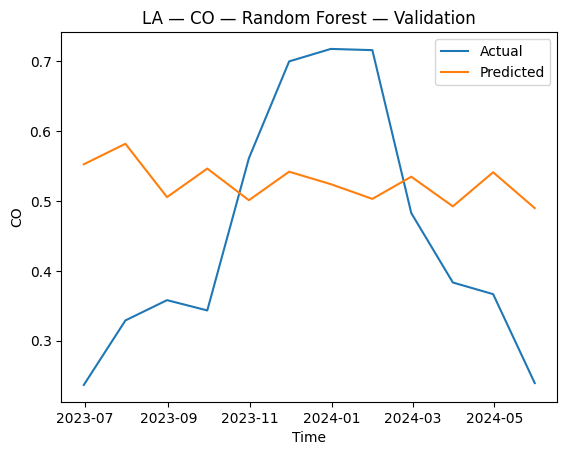

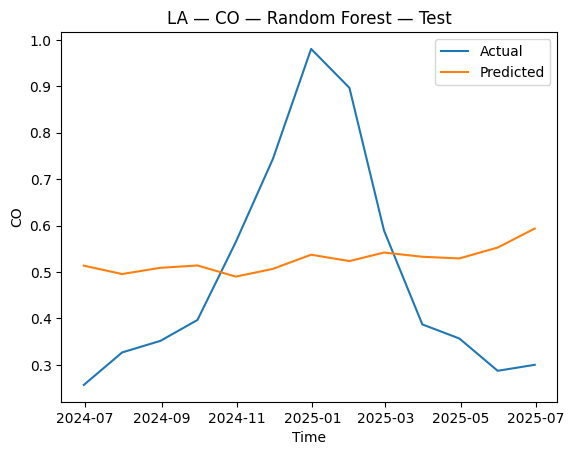

XGB [LA CO] [Val] MAE: 0.1814 | RMSE: 0.2036 | R^2: -0.4048
XGB [LA CO] [Test] MAE: 0.2026 | RMSE: 0.2348 | R^2: -0.0241


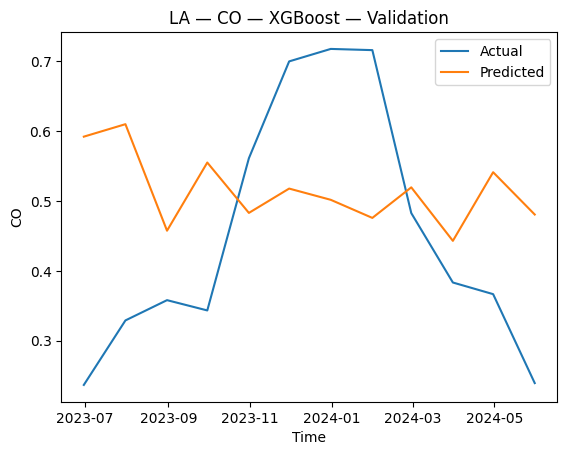

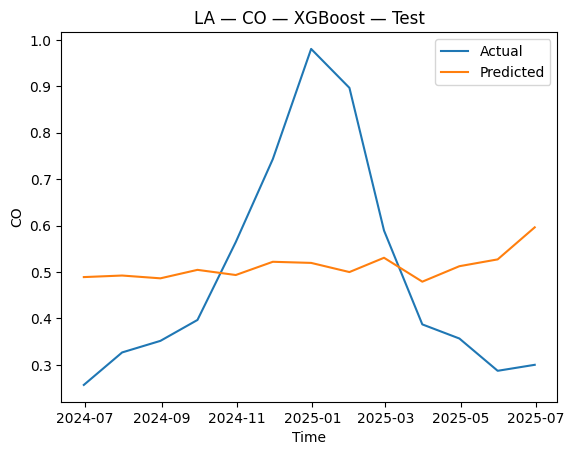

MLP [LA CO] [Val] MAE: 0.2924 | RMSE: 0.3340 | R^2: -2.7802
MLP [LA CO] [Test] MAE: 0.7808 | RMSE: 1.4581 | R^2: -38.4808


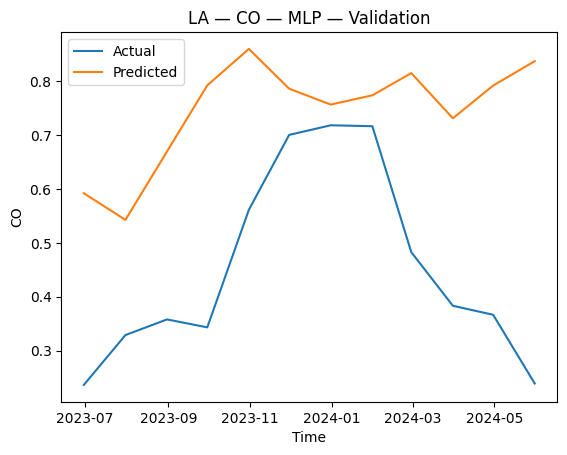

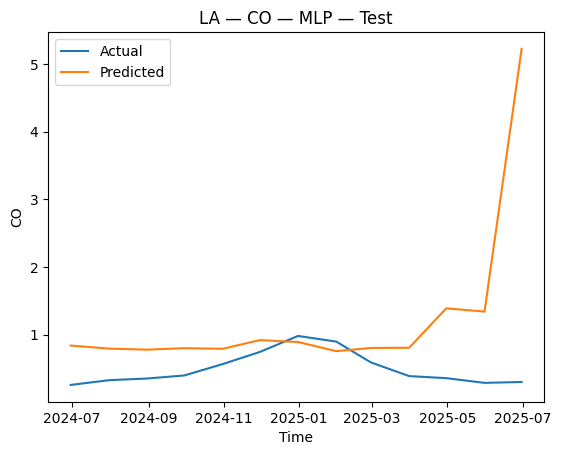

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
LSTM [LA CO] [Val] MAE: 0.3197 | RMSE: 0.3786 | R^2: -3.4712
LSTM [LA CO] [Test] MAE: 0.3657 | RMSE: 0.4620 | R^2: -1.9743


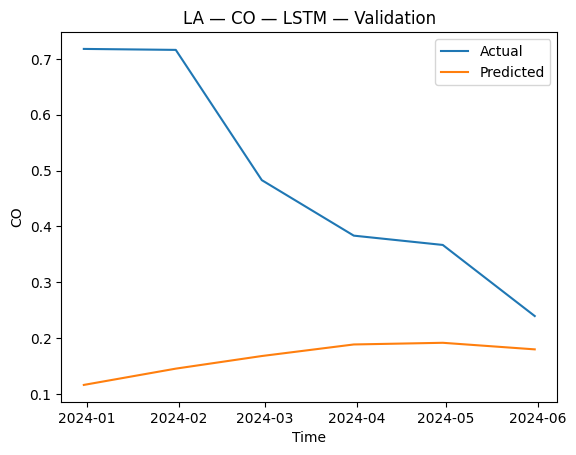

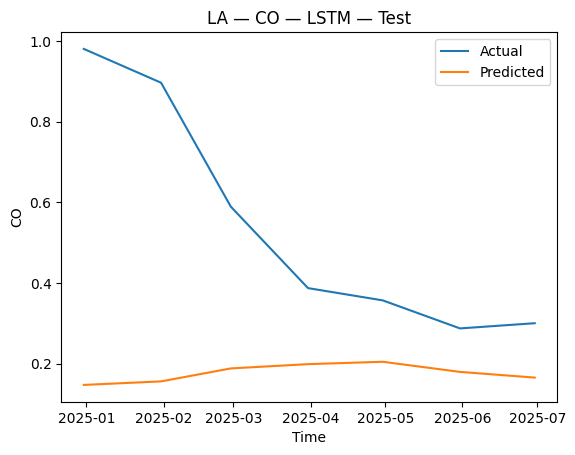

/tmp/ipython-input-1382105588.py:135: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, sample_X, show=True)


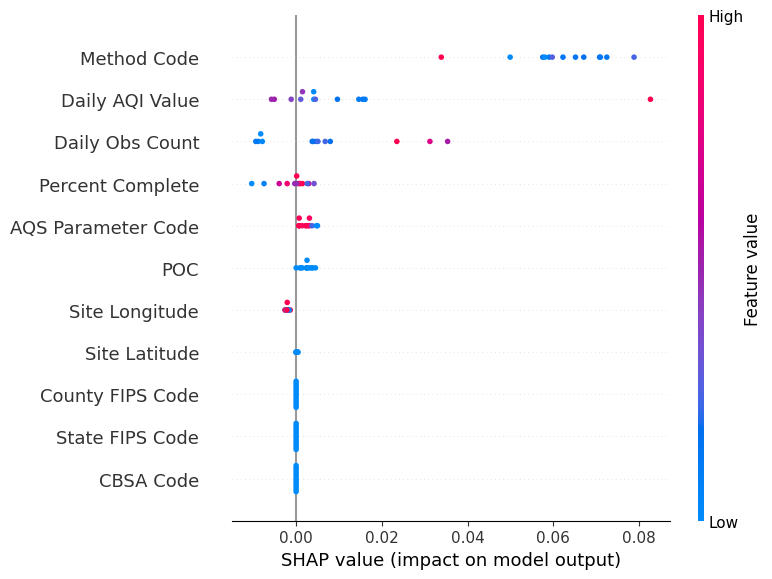

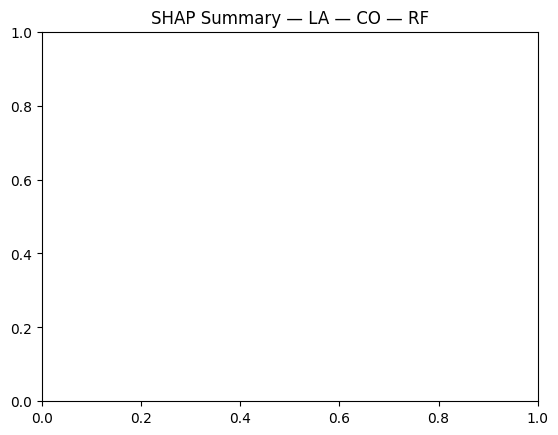

LIME not available.

CITY: NYC

[NYC] Skipping pollutant 'PM2.5': "Could not resolve column for target 'PM2.5'. Available columns: ['Date', 'POC', 'Daily Max 8-hour CO Concentration', 'Daily AQI Value', 'Daily Obs Count', 'Percent Complete', 'AQS Parameter Code', 'Method Code', 'CBSA Code', 'State FIPS Code', 'County FIPS Code', 'Site Latitude', 'Site Longitude']"
[NYC] Skipping pollutant 'NO2': "Could not resolve column for target 'NO2'. Available columns: ['Date', 'POC', 'Daily Max 8-hour CO Concentration', 'Daily AQI Value', 'Daily Obs Count', 'Percent Complete', 'AQS Parameter Code', 'Method Code', 'CBSA Code', 'State FIPS Code', 'County FIPS Code', 'Site Latitude', 'Site Longitude']"
[NYC] Skipping pollutant 'Ozone': "Could not resolve column for target 'Ozone'. Available columns: ['Date', 'POC', 'Daily Max 8-hour CO Concentration', 'Daily AQI Value', 'Daily Obs Count', 'Percent Complete', 'AQS Parameter Code', 'Method Code', 'CBSA Code', 'State FIPS Code', 'County FIPS Code', 'Si

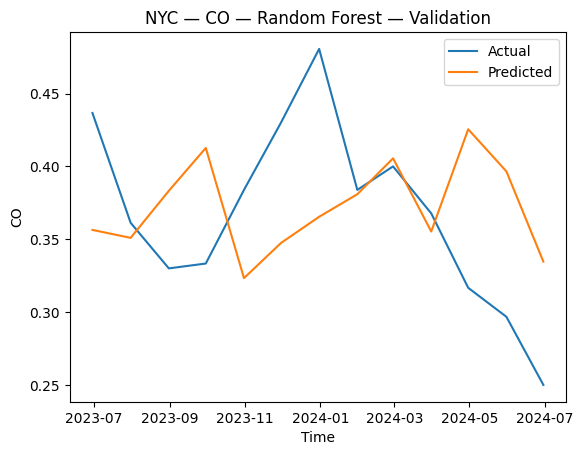

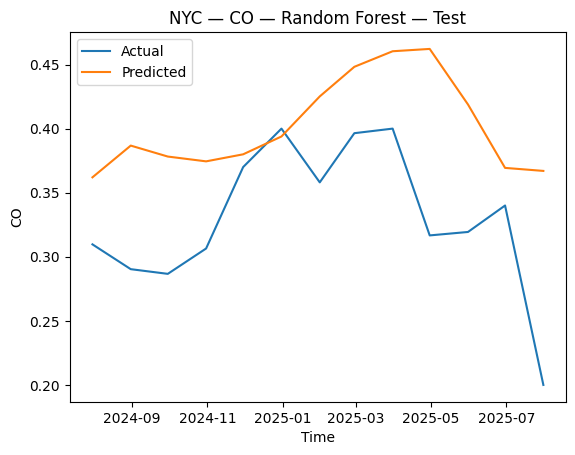

XGB [NYC CO] [Val] MAE: 0.0666 | RMSE: 0.0756 | R^2: -0.5765
XGB [NYC CO] [Test] MAE: 0.0699 | RMSE: 0.0847 | R^2: -1.4336


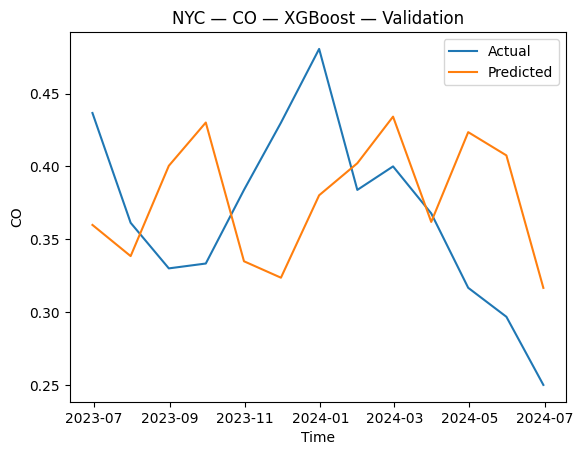

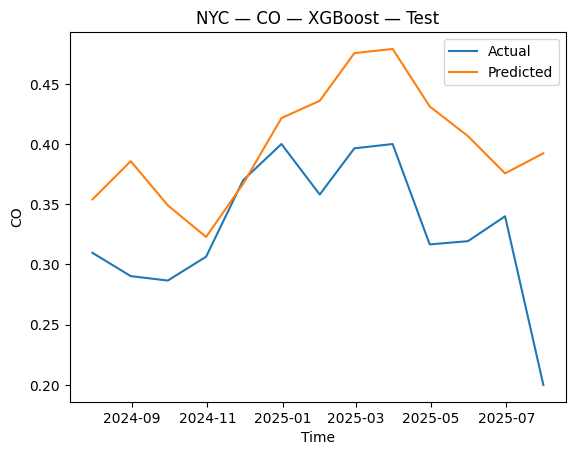

MLP [NYC CO] [Val] MAE: 0.0819 | RMSE: 0.0943 | R^2: -1.4538
MLP [NYC CO] [Test] MAE: 0.1103 | RMSE: 0.1434 | R^2: -5.9812


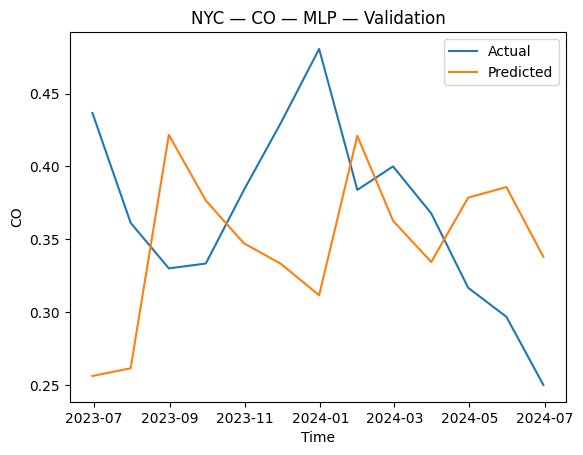

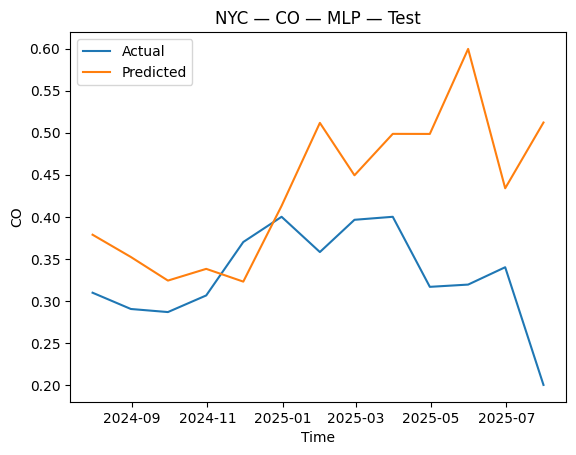

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
LSTM [NYC CO] [Val] MAE: 0.1030 | RMSE: 0.1247 | R^2: -2.1378
LSTM [NYC CO] [Test] MAE: 0.0555 | RMSE: 0.0950 | R^2: -1.3120


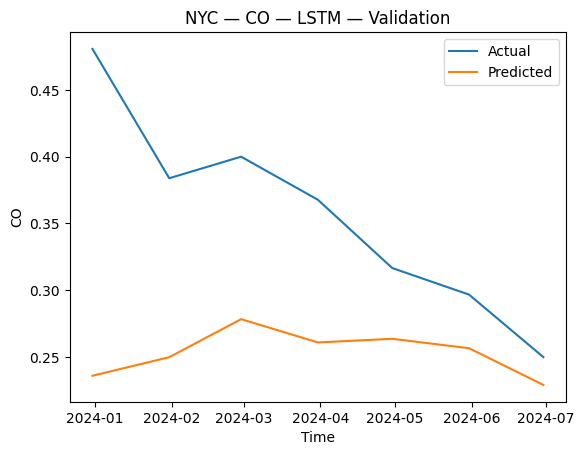

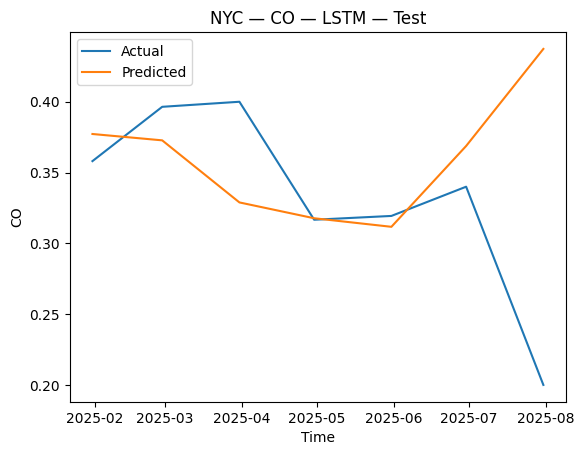

/tmp/ipython-input-1382105588.py:135: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, sample_X, show=True)


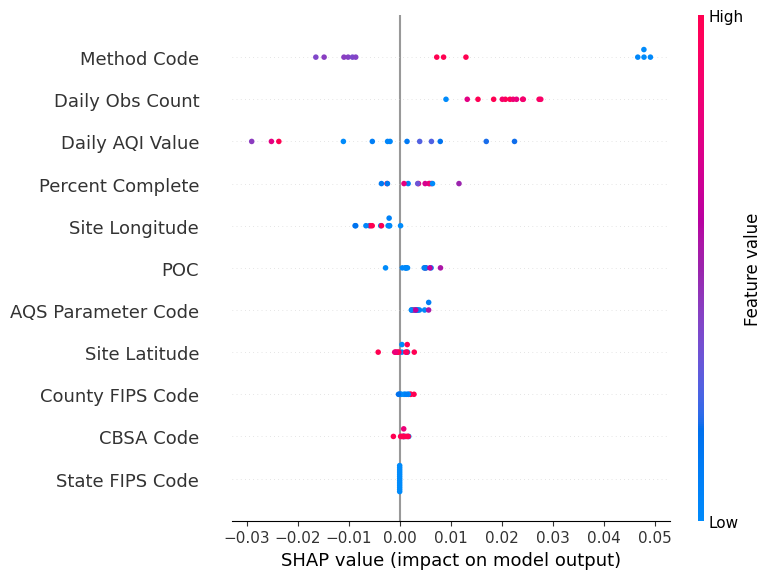

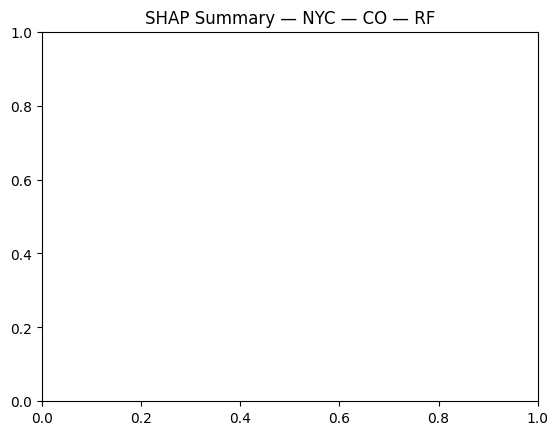

LIME not available.


In [9]:
ALL_RESULTS = []

for city, mdf in city_dfs.items():
    print("\n========================")
    print("CITY:", city)
    print("========================\n")
    for pollutant in POLLUTANTS:
        try:
            target_col = resolve_column(mdf, pollutant)
        except KeyError as e:
            print(f"[{city}] Skipping pollutant '{pollutant}':", e)
            continue

        # Features = all numeric except target
        feats = mdf.select_dtypes("number").columns.tolist()
        if target_col in feats:
            feats.remove(target_col)
        # If no features remain, skip
        if not feats:
            print(f"[{city}] No numeric features to predict {target_col}; skipping.")
            continue

        X = mdf[feats].copy()
        y = mdf[target_col].astype(float).copy()

        # Drop rows where the target variable is NaN
        valid_indices = y.dropna().index
        X = X.loc[valid_indices]
        y = y.loc[valid_indices]
        mdf_cleaned = mdf.loc[valid_indices]


        # Time split
        (X_train, y_train, df_train), (X_val, y_val, df_val), (X_test, y_test, df_test) = time_split(mdf_cleaned, X, y, TRAIN_FRAC, VAL_FRAC)

        # Scaling for MLP/LSTM
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_val_s   = scaler.transform(X_val)
        X_test_s  = scaler.transform(X_test)

        print(f"--- {city} | Target: {pollutant} (resolved: {target_col}) ---")
        print("Samples — train/val/test:", len(X_train), len(X_val), len(X_test))

        # ================= Random Forest =================
        rf = RandomForestRegressor(n_estimators=400, random_state=SEED, n_jobs=-1)
        rf.fit(X_train, y_train)
        rf_val_pred  = rf.predict(X_val)
        rf_test_pred = rf.predict(X_test)

        evaluate_regression(y_val, rf_val_pred,  f"RF [{city} {pollutant}] [Val]")
        evaluate_regression(y_test, rf_test_pred, f"RF [{city} {pollutant}] [Test]")

        plot_predictions(df_val, y_val, rf_val_pred, TIMESTAMP_COL, city, pollutant, "Random Forest — Validation")
        plot_predictions(df_test, y_test, rf_test_pred, TIMESTAMP_COL, city, pollutant, "Random Forest — Test")

        # ================= XGBoost =================
        if XGB_AVAILABLE:
            xgb = XGBRegressor(
                n_estimators=600, learning_rate=0.05, max_depth=6,
                subsample=0.8, colsample_bytree=0.8, random_state=SEED,
                n_jobs=-1, tree_method="hist"
            )
            xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
            xgb_val_pred  = xgb.predict(X_val)
            xgb_test_pred = xgb.predict(X_test)

            evaluate_regression(y_val, xgb_val_pred,  f"XGB [{city} {pollutant}] [Val]")
            evaluate_regression(y_test, xgb_test_pred, f"XGB [{city} {pollutant}] [Test]")

            plot_predictions(df_val, y_val, xgb_val_pred, TIMESTAMP_COL, city, pollutant, "XGBoost — Validation")
            plot_predictions(df_test, y_test, xgb_test_pred, TIMESTAMP_COL, city, pollutant, "XGBoost — Test")
        else:
            print("Skipping XGBoost — package unavailable.")

        # ================= MLP =================
        mlp = MLPRegressor(hidden_layer_sizes=(128,64), activation="relu",
                           solver="adam", learning_rate_init=1e-3, max_iter=300,
                           random_state=SEED)
        mlp.fit(X_train_s, y_train)
        mlp_val_pred  = mlp.predict(X_val_s)
        mlp_test_pred = mlp.predict(X_test_s)

        evaluate_regression(y_val, mlp_val_pred,  f"MLP [{city} {pollutant}] [Val]")
        evaluate_regression(y_test, mlp_test_pred, f"MLP [{city} {pollutant}] [Test]")

        plot_predictions(df_val, y_val, mlp_val_pred, TIMESTAMP_COL, city, pollutant, "MLP — Validation")
        plot_predictions(df_test, y_test, mlp_test_pred, TIMESTAMP_COL, city, pollutant, "MLP — Test")

        # ================= LSTM =================
        if KERAS_AVAILABLE:
            # LSTM needs enough monthly points
            if len(X_train_s) >= SEQ_LEN + 5 and X_val_s.shape[0] > SEQ_LEN and X_test_s.shape[0] > SEQ_LEN:
                X_tr_seq, y_tr_seq   = (lambda a,b: (a,b))(*make_sequences(X_train_s, y_train.values, SEQ_LEN))
                X_val_seq, y_val_seq = (lambda a,b: (a,b))(*make_sequences(X_val_s,   y_val.values,   SEQ_LEN))
                X_te_seq,  y_te_seq  = (lambda a,b: (a,b))(*make_sequences(X_test_s,  y_test.values,  SEQ_LEN))

                lstm = Sequential([
                    LSTM(64, input_shape=(X_tr_seq.shape[1], X_tr_seq.shape[2])),
                    Dropout(0.2),
                    Dense(32, activation="relu"),
                    Dense(1)
                ])
                lstm.compile(optimizer="adam", loss="mse")
                es = EarlyStopping(patience=10, restore_best_weights=True)
                lstm.fit(X_tr_seq, y_tr_seq, validation_data=(X_val_seq, y_val_seq),
                         epochs=100, batch_size=16, callbacks=[es], verbose=0)

                lstm_val_pred = lstm.predict(X_val_seq).ravel()
                lstm_test_pred = lstm.predict(X_te_seq).ravel()

                df_val_trim  = df_val.iloc[SEQ_LEN:].copy()
                df_test_trim = df_test.iloc[SEQ_LEN:].copy()
                y_val_trim   = y_val.iloc[SEQ_LEN:]
                y_test_trim  = y_test.iloc[SEQ_LEN:]


                evaluate_regression(y_val_trim, lstm_val_pred,  f"LSTM [{city} {pollutant}] [Val]")
                evaluate_regression(y_test_trim, lstm_test_pred, f"LSTM [{city} {pollutant}] [Test]")

                plot_predictions(df_val_trim,  y_val_trim,  lstm_val_pred,  TIMESTAMP_COL, city, pollutant, "LSTM — Validation")
                plot_predictions(df_test_trim, y_test_trim, lstm_test_pred, TIMESTAMP_COL, city, pollutant, "LSTM — Test")
            else:
                print(f"[{city}] LSTM skipped for {pollutant}: not enough monthly points for SEQ_LEN={SEQ_LEN}.")
        else:
            print("Skipping LSTM — Keras unavailable.")

        # ===== Explainability with SHAP & LIME (using RF as baseline explainer) =====
        try:
            if SHAP_AVAILABLE:
                try:
                    explainer = shap.TreeExplainer(rf)
                    sample_X = X_test.sample(min(200, len(X_test)), random_state=SEED)
                    shap_values = explainer.shap_values(sample_X)
                    shap.summary_plot(shap_values, sample_X, show=True)
                    plt.title(f"SHAP Summary — {city} — {pollutant} — RF")
                    plt.show()
                except Exception as e:
                    print(f"[{city}] SHAP TreeExplainer failed for {pollutant}:", e)
            else:
                print("SHAP not available.")

            if LIME_AVAILABLE and len(X_train_s) > 0 and len(X_test_s) > 0:
                explainer = LimeTabularExplainer(
                    training_data=np.array(X_train_s),
                    feature_names=list(feats),
                    mode="regression"
                )
                idx = min(5, len(X_test_s)-1)
                exp = explainer.explain_instance(X_test_s[idx], rf.predict, num_features=min(10, len(feats)))
                print(f"LIME explanation — {city} — {pollutant} — RF (one instance):")
                for item in exp.as_list():
                    print(item)
            else:
                if not LIME_AVAILABLE:
                    print("LIME not available.")
        except Exception as e:
            print(f"[{city}] Explainability skipped for {pollutant} due to error:", e)